In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

# Given architecture
layer_sizes = [20, 30, 30, 30, 30, 30, 30, 30, 30, 30, 1]
num_layers = len(layer_sizes) - 1

# Fixed input and target
X = np.ones((1, layer_sizes[0]))
y = np.array([[1]])

**Vanishing Gradient Effect (Random Small Weights)**

Layer 1 gradient norm : 0.000000
Layer 2 gradient norm : 0.000000
Layer 3 gradient norm : 0.000000
Layer 4 gradient norm : 0.000000
Layer 5 gradient norm : 0.000000
Layer 6 gradient norm : 0.000000
Layer 7 gradient norm : 0.000002
Layer 8 gradient norm : 0.000176
Layer 9 gradient norm : 0.014802
Layer 10 gradient norm : 1.370607


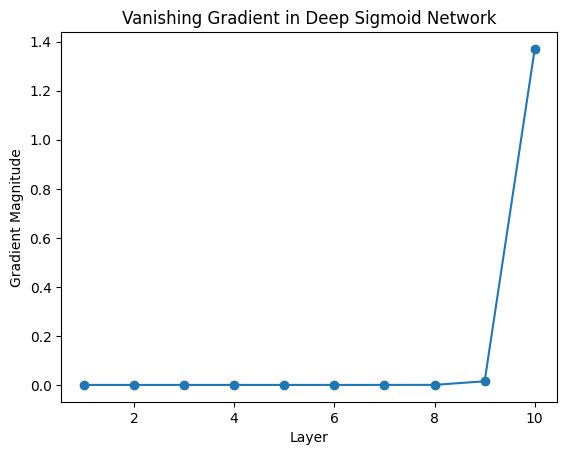

In [ ]:
weights = []
for i in range(num_layers):
    weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * 0.01)

activations = [X]
z_values = []

# Forward pass
for W in weights:
    z = activations[-1] @ W
    z_values.append(z)
    activations.append(sigmoid(z))

# Backward pass
delta = activations[-1] - y
gradients = []

for i in reversed(range(num_layers)):
    dW = activations[i].T @ delta
    gradients.append(np.linalg.norm(dW))
    delta = (delta @ weights[i].T) * sigmoid_derivative(activations[i])

gradients = gradients[::-1]

for i, g in enumerate(gradients):
    print(f"Layer {i+1} gradient norm : {g:.6f}")

plt.plot(range(1, num_layers+1), gradients, marker='o')
plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Vanishing Gradient in Deep Sigmoid Network")
plt.show()

**Symmetry Problem: All Weights = 0**

Gradient norms (All weights = 0) :
Layer 1 : 0.0
Layer 2 : 0.0
Layer 3 : 0.0
Layer 4 : 0.0
Layer 5 : 0.0
Layer 6 : 0.0
Layer 7 : 0.0
Layer 8 : 0.0
Layer 9 : 0.0
Layer 10 : 1.3693063937629153


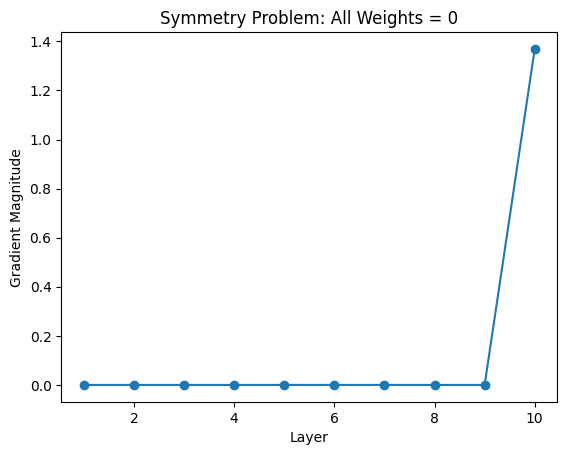

In [ ]:
weights = []
for i in range(num_layers):
    weights.append(np.zeros((layer_sizes[i], layer_sizes[i+1])))

activations = [X]

# Forward pass
for W in weights:
    activations.append(sigmoid(activations[-1] @ W))

# Backward pass
delta = activations[-1] - y
gradients_zero = []

for i in reversed(range(num_layers)):
    dW = activations[i].T @ delta
    gradients_zero.append(np.linalg.norm(dW))
    delta = (delta @ weights[i].T) * sigmoid_derivative(activations[i])

gradients_zero = gradients_zero[::-1]

print("Gradient norms (All weights = 0) :")
for i, g in enumerate(gradients_zero):
    print(f"Layer {i+1} : {g}")

plt.plot(range(1, num_layers+1), gradients_zero, marker='o')
plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Symmetry Problem: All Weights = 0")
plt.show()

**Symmetry Problem: All Weights = Same Random Number**

Gradient norms (All weights = same random value) :
Layer 1 : 1.1203078657590135e-08
Layer 2 : 3.966165773173387e-08
Layer 3 : 3.0237119470315494e-07
Layer 4 : 2.0912906716022395e-06
Layer 5 : 1.4659990447822902e-05
Layer 6 : 0.0001025684664105208
Layer 7 : 0.0007178172024598903
Layer 8 : 0.005023388163480922
Layer 9 : 0.035154591906746725
Layer 10 : 1.347496548146693


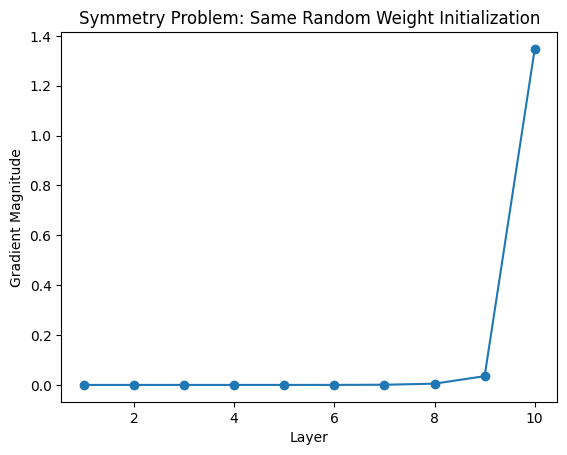

In [ ]:
weights = []
same_random_value = np.random.randn() * 0.1

for i in range(num_layers):
    weights.append(
        np.full((layer_sizes[i], layer_sizes[i+1]), same_random_value)
    )

activations = [X]

# Forward pass
for W in weights:
    activations.append(sigmoid(activations[-1] @ W))

# Backward pass
delta = activations[-1] - y
gradients_same_random = []

for i in reversed(range(num_layers)):
    dW = activations[i].T @ delta
    gradients_same_random.append(np.linalg.norm(dW))
    delta = (delta @ weights[i].T) * sigmoid_derivative(activations[i])

gradients_same_random = gradients_same_random[::-1]

print("Gradient norms (All weights = same random value) :")
for i, g in enumerate(gradients_same_random):
    print(f"Layer {i+1} : {g}")

plt.plot(range(1, num_layers+1), gradients_same_random, marker='o')
plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Symmetry Problem: Same Random Weight Initialization")
plt.show()

**Xavier Initialization (Fixing Symmetry)**

Layer 1 gradient norm : 0.000006
Layer 2 gradient norm : 0.000024
Layer 3 gradient norm : 0.000085
Layer 4 gradient norm : 0.000302
Layer 5 gradient norm : 0.002338
Layer 6 gradient norm : 0.009742
Layer 7 gradient norm : 0.039017
Layer 8 gradient norm : 0.168813
Layer 9 gradient norm : 0.593661
Layer 10 gradient norm : 1.927831


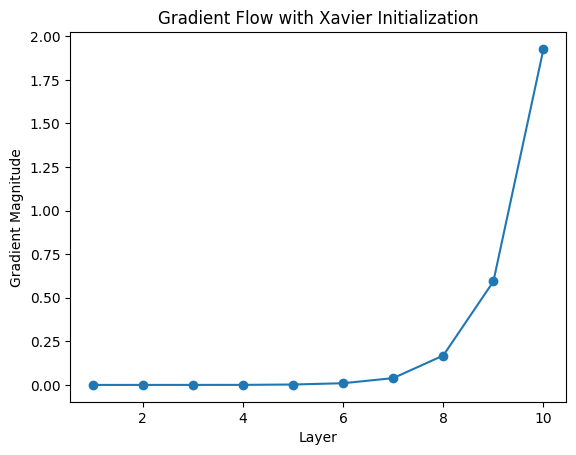

In [ ]:
weights = []
for i in range(num_layers):
    n_in = layer_sizes[i]
    n_out = layer_sizes[i+1]
    var = 2 / (n_in + n_out)
    W = np.random.randn(n_in, n_out) * np.sqrt(var)
    weights.append(W)

activations = [X]
z_values = []

# Forward pass
for W in weights:
    z = activations[-1] @ W
    z_values.append(z)
    activations.append(sigmoid(z))

delta = activations[-1] - y
gradients = []

# Backward Pass
for i in reversed(range(num_layers)): # Corrected L to num_layers
    dW = activations[i].T @ delta
    gradients.append(np.linalg.norm(dW))
    delta = (delta @ weights[i].T) * sigmoid_derivative(activations[i])

gradients = gradients[::-1]

# Print Gradients
for i, g in enumerate(gradients):
    print(f"Layer {i+1} gradient norm : {g:.6f}")

plt.plot(range(1, num_layers + 1), gradients, marker='o') # Corrected L to num_layers
plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Gradient Flow with Xavier Initialization")
plt.show()